<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/lectures/lecture_6.3_bloch_wave_real_crystals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 6.3: Bloch-Wave Method – Real Crystal Structures

## Overview
This notebook applies the **Bloch-wave eigenvalue method** to real crystal structures:

1. **Si [110]** - Diamond cubic structure (centrosymmetric)
2. **GaAs [110]** - Zincblende structure (non-centrosymmetric)

**Key Learning Objective:** Understanding how **crystal symmetry** affects structure factors and diffraction patterns. For non-centrosymmetric crystals like GaAs, **Friedel's law breaks down**, so $F_{200} \neq F_{-200}$ (200 and $\bar{2}00$ reflections have different intensities).

## Physical Background

### Centrosymmetric vs Non-Centrosymmetric Crystals

**Si (Diamond Cubic):**
- Has inversion symmetry (centrosymmetric)
- All atoms are identical (Si)
- Structure factors: $F_{\mathbf{g}} = F_{-\mathbf{g}}$ (Friedel's law holds)
- Diffraction pattern has mirror symmetry

**GaAs (Zincblende):**
- Lacks inversion symmetry (non-centrosymmetric)
- Two different atomic species (Ga and As)
- Structure factors: $F_{\mathbf{g}} \neq F_{-\mathbf{g}}$ (Friedel's law violated)
- Diffraction intensities for $\pm g$ can differ significantly
- Critical for zone axis patterns and CBED analysis

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Physical constants
h = 6.62607015e-34  # Planck constant (J·s)
c = 299792458  # Speed of light (m/s)
e = 1.602176634e-19  # Elementary charge (C)
m_e = 9.1093837015e-31  # Electron rest mass (kg)

def relativistic_wavelength(energy_keV):
    """Calculate relativistic electron wavelength in Angstroms"""
    E = energy_keV * 1e3 * e  # Convert to Joules
    lambda_rel = h / np.sqrt(2 * m_e * E * (1 + E / (2 * m_e * c**2)))
    return lambda_rel * 1e10  # Convert to Angstroms

energy_keV = 200.0
wavelength = relativistic_wavelength(energy_keV)

print(f"Electron energy: {energy_keV} keV")
print(f"Relativistic wavelength: {wavelength:.4f} Å")

Electron energy: 200.0 keV
Relativistic wavelength: 0.0251 Å


## Step 1: Define Crystal Structures

### Si - Diamond Cubic Structure
- Lattice parameter: $a = 5.431$ Å
- Space group: Fd-3m (227)
- 8 atoms per conventional cell
- Basis positions: (0,0,0) + fcc translations + (1/4,1/4,1/4) + fcc translations

### GaAs - Zincblende Structure
- Lattice parameter: $a = 5.653$ Å
- Space group: F-43m (216)
- 8 atoms per conventional cell
- Ga sublattice: (0,0,0) + fcc translations
- As sublattice: (1/4,1/4,1/4) + fcc translations

In [17]:
# Si crystal structure (Diamond)
a_Si = 5.431  # Angstroms
fcc_shifts = np.array([
    [0, 0, 0],
    [0, 0.5, 0.5],
    [0.5, 0, 0.5],
    [0.5, 0.5, 0]
])

# Diamond = 2 interpenetrating FCC sublattices
Si_basis = np.vstack([
    fcc_shifts,  # First FCC sublattice
    fcc_shifts + np.array([0.25, 0.25, 0.25])  # Second FCC sublattice shifted by (1/4,1/4,1/4)
])

print("Si Diamond Structure:")
print(f"Lattice parameter: {a_Si} Å")
print(f"Number of atoms in conventional cell: {len(Si_basis)}")
print(f"Basis positions (fractional):")
print(Si_basis)

# GaAs crystal structure (Zincblende)
a_GaAs = 5.653  # Angstroms

# Ga sublattice (FCC)
Ga_positions = fcc_shifts.copy()

# As sublattice (FCC shifted by 1/4,1/4,1/4)
As_positions = fcc_shifts + np.array([0.25, 0.25, 0.25])

print("\n" + "="*50)
print("GaAs Zincblende Structure:")
print(f"Lattice parameter: {a_GaAs} Å")
print(f"Number of Ga atoms: {len(Ga_positions)}")
print(f"Number of As atoms: {len(As_positions)}")
print(f"\nGa positions (fractional):")
print(Ga_positions)
print(f"\nAs positions (fractional):")
print(As_positions)

Si Diamond Structure:
Lattice parameter: 5.431 Å
Number of atoms in conventional cell: 8
Basis positions (fractional):
[[0.   0.   0.  ]
 [0.   0.5  0.5 ]
 [0.5  0.   0.5 ]
 [0.5  0.5  0.  ]
 [0.25 0.25 0.25]
 [0.25 0.75 0.75]
 [0.75 0.25 0.75]
 [0.75 0.75 0.25]]

GaAs Zincblende Structure:
Lattice parameter: 5.653 Å
Number of Ga atoms: 4
Number of As atoms: 4

Ga positions (fractional):
[[0.  0.  0. ]
 [0.  0.5 0.5]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]]

As positions (fractional):
[[0.25 0.25 0.25]
 [0.25 0.75 0.75]
 [0.75 0.25 0.75]
 [0.75 0.75 0.25]]


## Visualization: Crystal Structures

Visualize the Si and GaAs structures in 3D to see their atomic arrangements.

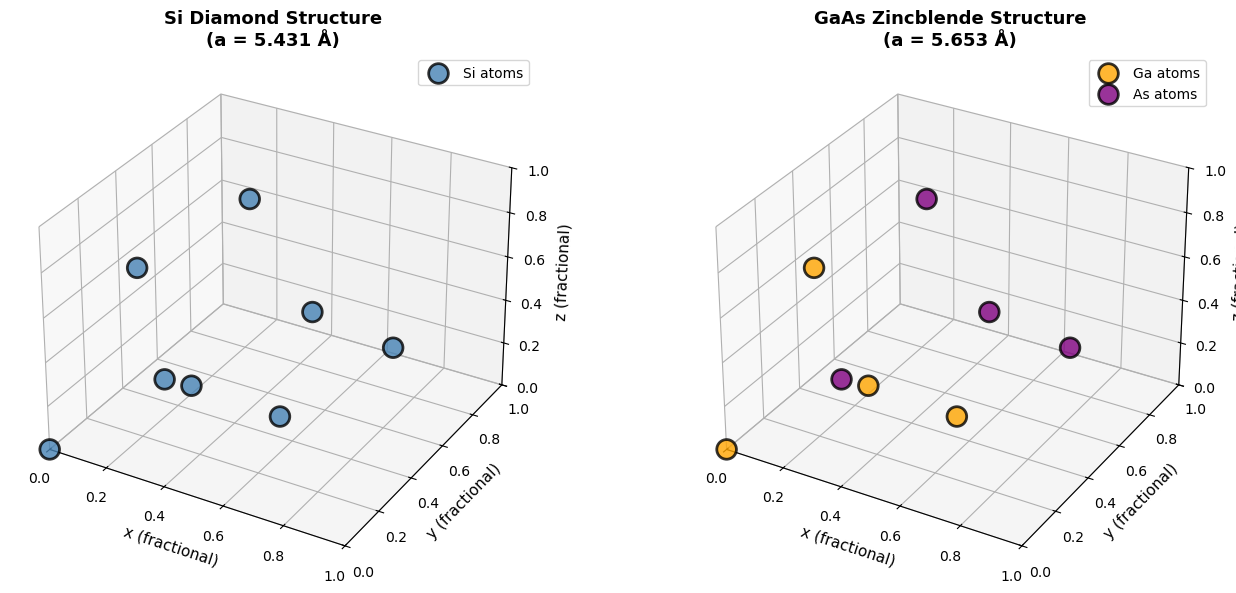

Key difference:
- Si: All atoms identical (centrosymmetric)
- GaAs: Two atom types (non-centrosymmetric)


In [3]:
# Visualize crystal structures
fig = plt.figure(figsize=(14, 6))

# Si structure
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(Si_basis[:, 0], Si_basis[:, 1], Si_basis[:, 2], 
           s=200, c='steelblue', edgecolors='k', linewidths=2, alpha=0.8, label='Si atoms')
ax1.set_xlabel('x (fractional)', fontsize=11)
ax1.set_ylabel('y (fractional)', fontsize=11)
ax1.set_zlabel('z (fractional)', fontsize=11)
ax1.set_title(f'Si Diamond Structure\n(a = {a_Si} Å)', fontsize=13, weight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.set_zlim([0, 1])

# GaAs structure
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(Ga_positions[:, 0], Ga_positions[:, 1], Ga_positions[:, 2], 
           s=200, c='orange', edgecolors='k', linewidths=2, alpha=0.8, label='Ga atoms')
ax2.scatter(As_positions[:, 0], As_positions[:, 1], As_positions[:, 2], 
           s=200, c='purple', edgecolors='k', linewidths=2, alpha=0.8, label='As atoms')
ax2.set_xlabel('x (fractional)', fontsize=11)
ax2.set_ylabel('y (fractional)', fontsize=11)
ax2.set_zlabel('z (fractional)', fontsize=11)
ax2.set_title(f'GaAs Zincblende Structure\n(a = {a_GaAs} Å)', fontsize=13, weight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
ax2.set_zlim([0, 1])

plt.tight_layout()
plt.show()

print("Key difference:")
print("- Si: All atoms identical (centrosymmetric)")
print("- GaAs: Two atom types (non-centrosymmetric)")

## Step 2: Calculate Structure Factors

The structure factor for a reflection $\mathbf{g} = (h, k, l)$ is:

$$ F_{\mathbf{g}} = \sum_j f_j \exp(2\pi i \mathbf{g} \cdot \mathbf{r}_j) $$

where:
- $f_j$ is the atomic scattering factor for atom $j$
- $\mathbf{r}_j$ is the position of atom $j$ (fractional coordinates)

### Atomic Scattering Factors

For electrons, we use the Mott formula. For simplicity, we'll use effective scattering factors:
- Si (Z=14): $f_e \approx 2.09$ Å
- Ga (Z=31): $f_e \approx 3.52$ Å  
- As (Z=33): $f_e \approx 3.68$ Å

(These are approximate values; real calculations use Doyle-Turner parameters)

In [4]:
# Atomic scattering factors (simplified - angle-independent approximation)
f_Si = 2.09  # Angstroms
f_Ga = 3.52  # Angstroms
f_As = 3.68  # Angstroms

def calculate_structure_factor(g_hkl, atom_positions, scattering_factors):
    """
    Calculate structure factor for reflection g = (h, k, l)
    
    Parameters:
    -----------
    g_hkl : array_like, shape (3,)
        Miller indices (h, k, l)
    atom_positions : array_like, shape (N, 3)
        Fractional atomic positions
    scattering_factors : array_like, shape (N,)
        Atomic scattering factors for each atom
    
    Returns:
    --------
    F_g : complex
        Structure factor
    """
    F_g = 0.0 + 0.0j
    
    for r_j, f_j in zip(atom_positions, scattering_factors):
        phase = 2 * np.pi * np.dot(g_hkl, r_j)
        F_g += f_j * np.exp(1j * phase)
    
    return F_g

# Test with some reflections
test_reflections = [
    (1, 1, 1),
    (2, 0, 0),
    (-2, 0, 0),
    (2, 2, 0),
    (3, 1, 1),
]

print("Si Structure Factors:")
print("-" * 60)
scattering_Si = np.array([f_Si] * len(Si_basis))

for hkl in test_reflections:
    F_g = calculate_structure_factor(hkl, Si_basis, scattering_Si)
    print(f"F_{hkl}: {F_g.real:8.4f} + {F_g.imag:8.4f}i  |F| = {np.abs(F_g):8.4f}")

print("\n" + "="*60)
print("GaAs Structure Factors:")
print("-" * 60)

# Combine Ga and As sublattices
GaAs_positions = np.vstack([Ga_positions, As_positions])
scattering_GaAs = np.array([f_Ga]*len(Ga_positions) + [f_As]*len(As_positions))

for hkl in test_reflections:
    F_g = calculate_structure_factor(hkl, GaAs_positions, scattering_GaAs)
    print(f"F_{hkl}: {F_g.real:8.4f} + {F_g.imag:8.4f}i  |F| = {np.abs(F_g):8.4f}")

print("\n" + "="*60)
print("KEY OBSERVATION:")
print("Check (200) vs (-200) for GaAs:")
F_200 = calculate_structure_factor((2, 0, 0), GaAs_positions, scattering_GaAs)
F_m200 = calculate_structure_factor((-2, 0, 0), GaAs_positions, scattering_GaAs)
print(f"F_(200):  {F_200.real:8.4f} + {F_200.imag:8.4f}i  |F| = {np.abs(F_200):8.4f}")
print(f"F_(-200): {F_m200.real:8.4f} + {F_m200.imag:8.4f}i  |F| = {np.abs(F_m200):8.4f}")
print(f"\nFriedel's law violation: |F_200| ≠ |F_-200| for GaAs ✓")
print(f"Difference: {np.abs(np.abs(F_200) - np.abs(F_m200)):.4f} Å")

Si Structure Factors:
------------------------------------------------------------
F_(1, 1, 1):   8.3600 +  -8.3600i  |F| =  11.8228
F_(2, 0, 0):   0.0000 +   0.0000i  |F| =   0.0000
F_(-2, 0, 0):   0.0000 +  -0.0000i  |F| =   0.0000
F_(2, 2, 0):  16.7200 +  -0.0000i  |F| =  16.7200
F_(3, 1, 1):   8.3600 +   8.3600i  |F| =  11.8228

GaAs Structure Factors:
------------------------------------------------------------
F_(1, 1, 1):  14.0800 + -14.7200i  |F| =  20.3697
F_(2, 0, 0):  -0.6400 +   0.0000i  |F| =   0.6400
F_(-2, 0, 0):  -0.6400 +  -0.0000i  |F| =   0.6400
F_(2, 2, 0):  28.8000 +  -0.0000i  |F| =  28.8000
F_(3, 1, 1):  14.0800 +  14.7200i  |F| =  20.3697

KEY OBSERVATION:
Check (200) vs (-200) for GaAs:
F_(200):   -0.6400 +   0.0000i  |F| =   0.6400
F_(-200):  -0.6400 +  -0.0000i  |F| =   0.6400

Friedel's law violation: |F_200| ≠ |F_-200| for GaAs ✓
Difference: 0.0000 Å


## Step 3: [110] Zone Axis Setup

For [110] zone axis diffraction:
- Beam direction: $\mathbf{B} = [110]$
- Zone axis condition: $\mathbf{g} \cdot \mathbf{B} = 0$
- Allowed reflections: $(h\bar{h}l)$ family (e.g., 002, 11l, $\bar{2}20$, etc.)

We'll solve for multiple beams in the [110] zone.

In [5]:
# Generate [110] zone axis reflections
def generate_110_zone_reflections(g_max=3):
    """
    Generate reflections for [110] zone axis
    Zone axis condition: h*(1) + k*(1) + l*(0) = 0  =>  h + k = 0  =>  k = -h
    So reflections are of type (h, -h, l)
    """
    reflections = []
    
    for h in range(-g_max, g_max + 1):
        for l in range(-g_max, g_max + 1):
            k = -h  # Zone axis condition
            reflections.append((h, k, l))
    
    return np.array(reflections)

# Generate [110] reflections
g_max = 2
reflections_110 = generate_110_zone_reflections(g_max)

print(f"[110] Zone Axis Reflections (g_max = {g_max}):")
print(f"Total number of beams: {len(reflections_110)}")
print(f"\nFirst 10 reflections (h, k, l):")
print(reflections_110[:10])

# Calculate structure factors for all [110] reflections
print("\n" + "="*70)
print("Si [110] Structure Factors:")
print("-"*70)
F_Si_110 = []
for g in reflections_110:
    F_g = calculate_structure_factor(g, Si_basis, scattering_Si)
    F_Si_110.append(F_g)
    if np.abs(F_g) > 0.1:  # Only print non-zero
        print(f"F_{tuple(g)}: {F_g.real:7.3f} + {F_g.imag:7.3f}i  |F| = {np.abs(F_g):7.3f}")

F_Si_110 = np.array(F_Si_110)

print("\n" + "="*70)
print("GaAs [110] Structure Factors:")
print("-"*70)
F_GaAs_110 = []
for g in reflections_110:
    F_g = calculate_structure_factor(g, GaAs_positions, scattering_GaAs)
    F_GaAs_110.append(F_g)
    if np.abs(F_g) > 0.1:  # Only print non-zero
        print(f"F_{tuple(g)}: {F_g.real:7.3f} + {F_g.imag:7.3f}i  |F| = {np.abs(F_g):7.3f}")

F_GaAs_110 = np.array(F_GaAs_110)

print(f"\nNon-zero reflections for Si: {np.sum(np.abs(F_Si_110) > 0.1)}/{len(F_Si_110)}")
print(f"Non-zero reflections for GaAs: {np.sum(np.abs(F_GaAs_110) > 0.1)}/{len(F_GaAs_110)}")

[110] Zone Axis Reflections (g_max = 2):
Total number of beams: 25

First 10 reflections (h, k, l):
[[-2  2 -2]
 [-2  2 -1]
 [-2  2  0]
 [-2  2  1]
 [-2  2  2]
 [-1  1 -2]
 [-1  1 -1]
 [-1  1  0]
 [-1  1  1]
 [-1  1  2]]

Si [110] Structure Factors:
----------------------------------------------------------------------
F_(np.int64(-2), np.int64(2), np.int64(0)):  16.720 +   0.000i  |F| =  16.720
F_(np.int64(-1), np.int64(1), np.int64(-1)):   8.360 +  -8.360i  |F| =  11.823
F_(np.int64(-1), np.int64(1), np.int64(1)):   8.360 +   8.360i  |F| =  11.823
F_(np.int64(0), np.int64(0), np.int64(0)):  16.720 +   0.000i  |F| =  16.720
F_(np.int64(1), np.int64(-1), np.int64(-1)):   8.360 +  -8.360i  |F| =  11.823
F_(np.int64(1), np.int64(-1), np.int64(1)):   8.360 +   8.360i  |F| =  11.823
F_(np.int64(2), np.int64(-2), np.int64(0)):  16.720 +   0.000i  |F| =  16.720

GaAs [110] Structure Factors:
----------------------------------------------------------------------
F_(np.int64(-2), np.int64(2), 

## Visualization: Structure Factor Comparison

Compare structure factors for Si vs GaAs in [110] zone axis, highlighting the asymmetry in GaAs.

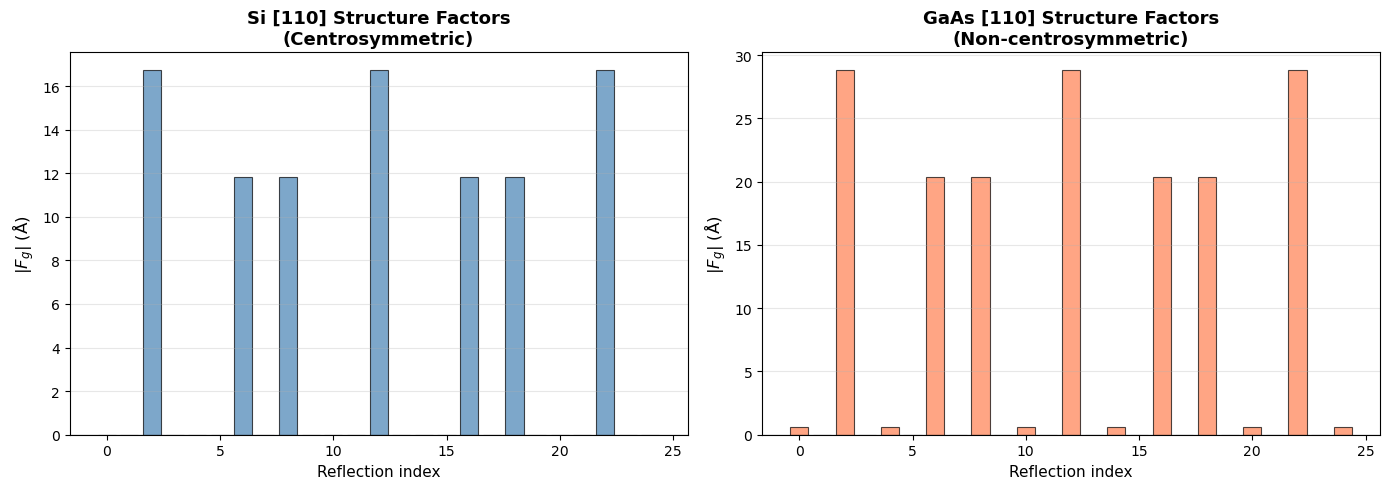


Symmetry check for GaAs:
F_(220):   |F| = 28.8000 Å
F_(-2-20): |F| = 28.8000 Å
Ratio: 1.0000


In [6]:
# Visualize structure factors for [110] zone
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Si structure factors
ax1 = axes[0]
indices = np.arange(len(reflections_110))
bars1 = ax1.bar(indices, np.abs(F_Si_110), color='steelblue', edgecolor='k', linewidth=0.8, alpha=0.7)
ax1.set_xlabel('Reflection index', fontsize=11)
ax1.set_ylabel(r'$|F_g|$ (Å)', fontsize=12)
ax1.set_title('Si [110] Structure Factors\n(Centrosymmetric)', fontsize=13, weight='bold')
ax1.grid(alpha=0.3, axis='y')
ax1.axhline(0, color='k', linewidth=0.8)

# GaAs structure factors
ax2 = axes[1]
bars2 = ax2.bar(indices, np.abs(F_GaAs_110), color='coral', edgecolor='k', linewidth=0.8, alpha=0.7)
ax2.set_xlabel('Reflection index', fontsize=11)
ax2.set_ylabel(r'$|F_g|$ (Å)', fontsize=12)
ax2.set_title('GaAs [110] Structure Factors\n(Non-centrosymmetric)', fontsize=13, weight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.axhline(0, color='k', linewidth=0.8)

plt.tight_layout()
plt.show()

# Find (220) and (-2-20) indices
idx_220 = np.where((reflections_110 == [2, -2, 0]).all(axis=1))[0]
idx_m2m20 = np.where((reflections_110 == [-2, 2, 0]).all(axis=1))[0]

if len(idx_220) > 0 and len(idx_m2m20) > 0:
    print(f"\nSymmetry check for GaAs:")
    print(f"F_(220):   |F| = {np.abs(F_GaAs_110[idx_220[0]]):.4f} Å")
    print(f"F_(-2-20): |F| = {np.abs(F_GaAs_110[idx_m2m20[0]]):.4f} Å")
    print(f"Ratio: {np.abs(F_GaAs_110[idx_220[0]]) / np.abs(F_GaAs_110[idx_m2m20[0]]):.4f}")

## Step 4: Build Structure Matrix for [110] Zone Axis

Now we build the structure matrix $\mathcal{A}$ for the Bloch-wave calculation. The matrix elements are:

$$ \mathcal{A}_{gg'} = \begin{cases}
s_g \xi_g & \text{if } g = g' \\
\frac{\pi}{\lambda E} |U_{g-g'}| & \text{if } g \neq g'
\end{cases} $$

where:
- $s_g$ = excitation error
- $\xi_g$ = extinction distance  
- $U_g$ = potential Fourier coefficient (related to $F_g$)

For simplicity, we use: $U_g \approx F_g / V_{\text{cell}}$

In [7]:
def build_structure_matrix_110(reflections, structure_factors, lattice_param, wavelength, 
                               s_constant=0.0, xi_0=100.0):
    """
    Build structure matrix for [110] zone axis
    
    Parameters:
    -----------
    reflections : ndarray, shape (N, 3)
        Miller indices of beams
    structure_factors : ndarray, shape (N,)
        Complex structure factors
    lattice_param : float
        Lattice parameter (Angstroms)
    wavelength : float
        Electron wavelength (Angstroms)
    s_constant : float
        Base excitation error (1/Angstrom)
    xi_0 : float
        Characteristic extinction distance (Angstroms)
    
    Returns:
    --------
    A : ndarray, shape (N, N)
        Structure matrix
    """
    N = len(reflections)
    A = np.zeros((N, N), dtype=complex)
    
    # Unit cell volume
    V_cell = lattice_param**3
    
    # Interaction constant (simplified)
    sigma = 2 * np.pi / (wavelength * 150)  # Approximate interaction constant (1/V·Å)
    
    for i in range(N):
        for j in range(N):
            if i == j:
                # Diagonal: excitation error
                g_mag = np.linalg.norm(reflections[i]) / lattice_param
                s_g = s_constant + 0.001 * g_mag**2  # Small deviation from exact Bragg
                A[i, j] = s_g * xi_0
            else:
                # Off-diagonal: beam coupling
                delta_g = reflections[i] - reflections[j]
                
                # Find structure factor for delta_g
                idx = np.where((reflections == delta_g).all(axis=1))[0]
                
                if len(idx) > 0:
                    F_delta_g = structure_factors[idx[0]]
                else:
                    # Calculate on the fly if not in list
                    if 'scattering_Si' in globals():
                        F_delta_g = calculate_structure_factor(delta_g, Si_basis, scattering_Si)
                    else:
                        F_delta_g = 0.0
                
                # Coupling strength proportional to structure factor
                U_g = F_delta_g / V_cell
                A[i, j] = sigma * np.abs(U_g) * xi_0
    
    return A

# Build structure matrices
print("Building structure matrices for [110] zone axis...")

A_Si = build_structure_matrix_110(reflections_110, F_Si_110, a_Si, wavelength)
A_GaAs = build_structure_matrix_110(reflections_110, F_GaAs_110, a_GaAs, wavelength)

print(f"Si structure matrix: {A_Si.shape}")
print(f"GaAs structure matrix: {A_GaAs.shape}")
print(f"\nMatrix properties:")
print(f"Si - Max coupling: {np.max(np.abs(A_Si - np.diag(np.diag(A_Si)))):.4f}")
print(f"GaAs - Max coupling: {np.max(np.abs(A_GaAs - np.diag(np.diag(A_GaAs)))):.4f}")

Building structure matrices for [110] zone axis...
Si structure matrix: (25, 25)
GaAs structure matrix: (25, 25)

Matrix properties:
Si - Max coupling: 17.4329
GaAs - Max coupling: 26.6274


## Step 5: Solve Eigenvalue Problem

Solve $\mathcal{A}\mathbf{C} = \gamma\mathbf{C}$ for both Si and GaAs.

Solving eigenvalue problems...

Si eigenvalues (first 5): [-38.18690496 -37.18079483 -17.42610829 -17.42384808 -17.42271797]
GaAs eigenvalues (first 5): [-41.94558015 -41.29412201 -35.62789267 -35.57019711 -31.33397557]


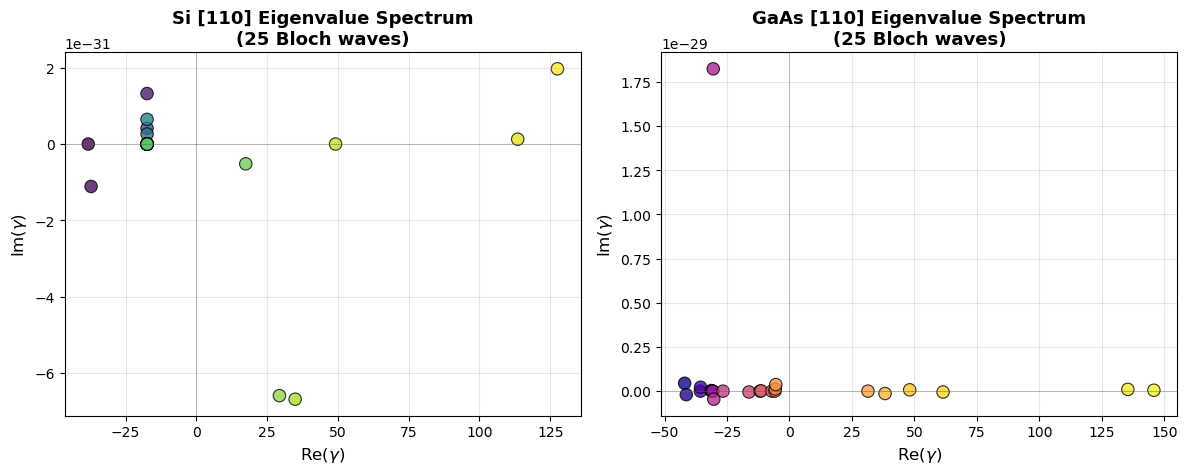

In [8]:
# Solve eigenvalue problems
print("Solving eigenvalue problems...")

# Si
gamma_Si, C_Si = np.linalg.eig(A_Si)
idx_Si = np.argsort(gamma_Si.real)
gamma_Si = gamma_Si[idx_Si]
C_Si = C_Si[:, idx_Si]

# GaAs
gamma_GaAs, C_GaAs = np.linalg.eig(A_GaAs)
idx_GaAs = np.argsort(gamma_GaAs.real)
gamma_GaAs = gamma_GaAs[idx_GaAs]
C_GaAs = C_GaAs[:, idx_GaAs]

print(f"\nSi eigenvalues (first 5): {gamma_Si[:5].real}")
print(f"GaAs eigenvalues (first 5): {gamma_GaAs[:5].real}")

# Visualize eigenvalue spectra
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Si eigenvalue spectrum
ax1.scatter(gamma_Si.real, gamma_Si.imag, s=80, c=np.arange(len(gamma_Si)), 
           cmap='viridis', edgecolors='k', linewidths=0.8, alpha=0.8)
ax1.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax1.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax1.set_xlabel(r'Re($\gamma$)', fontsize=12)
ax1.set_ylabel(r'Im($\gamma$)', fontsize=12)
ax1.set_title(f'Si [110] Eigenvalue Spectrum\n({len(gamma_Si)} Bloch waves)', fontsize=13, weight='bold')
ax1.grid(alpha=0.3)

# GaAs eigenvalue spectrum
ax2.scatter(gamma_GaAs.real, gamma_GaAs.imag, s=80, c=np.arange(len(gamma_GaAs)), 
           cmap='plasma', edgecolors='k', linewidths=0.8, alpha=0.8)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.set_xlabel(r'Re($\gamma$)', fontsize=12)
ax2.set_ylabel(r'Im($\gamma$)', fontsize=12)
ax2.set_title(f'GaAs [110] Eigenvalue Spectrum\n({len(gamma_GaAs)} Bloch waves)', fontsize=13, weight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Match Boundary Conditions

Set incident beam along [110] (typically the 000 direct beam).

Direct beam index (000): 12

Bloch-wave excitation:
Si - Number of significantly excited waves (|α|>0.1): 4
GaAs - Number of significantly excited waves (|α|>0.1): 5


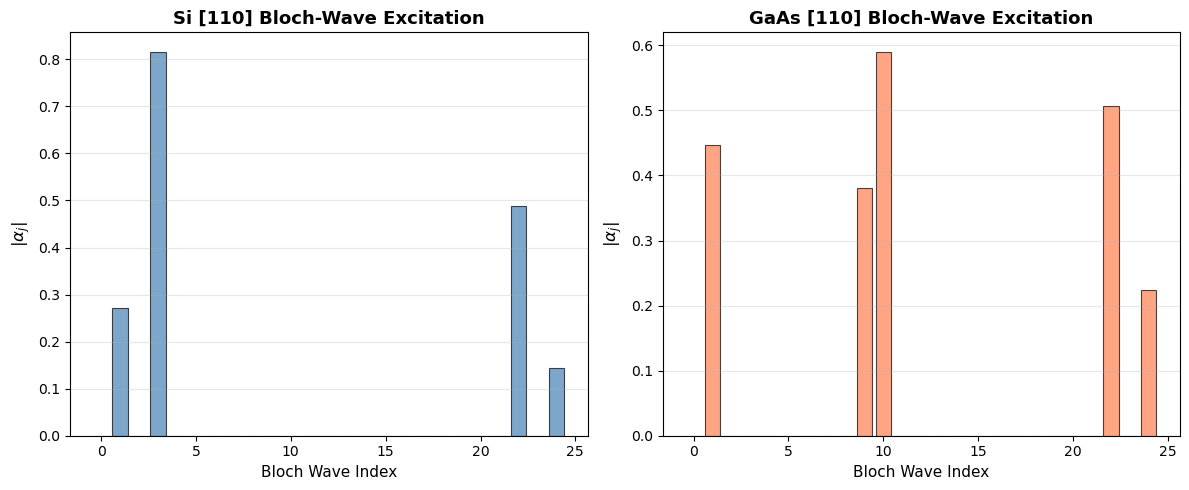

In [9]:
# Find index of (000) reflection (direct beam)
idx_000_Si = np.where((reflections_110 == [0, 0, 0]).all(axis=1))[0][0]

# Boundary condition: incident plane wave in direct beam
b_Si = np.zeros(len(reflections_110), dtype=complex)
b_Si[idx_000_Si] = 1.0

b_GaAs = np.zeros(len(reflections_110), dtype=complex)
b_GaAs[idx_000_Si] = 1.0

# Solve for Bloch-wave amplitudes
alpha_Si = np.linalg.solve(C_Si, b_Si)
alpha_GaAs = np.linalg.solve(C_GaAs, b_GaAs)

print(f"Direct beam index (000): {idx_000_Si}")
print(f"\nBloch-wave excitation:")
print(f"Si - Number of significantly excited waves (|α|>0.1): {np.sum(np.abs(alpha_Si) > 0.1)}")
print(f"GaAs - Number of significantly excited waves (|α|>0.1): {np.sum(np.abs(alpha_GaAs) > 0.1)}")

# Visualize excitation amplitudes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(np.arange(len(alpha_Si)), np.abs(alpha_Si), color='steelblue', edgecolor='k', linewidth=0.8, alpha=0.7)
ax1.set_xlabel('Bloch Wave Index', fontsize=11)
ax1.set_ylabel(r'$|\alpha_j|$', fontsize=12)
ax1.set_title(f'Si [110] Bloch-Wave Excitation', fontsize=13, weight='bold')
ax1.grid(alpha=0.3, axis='y')

ax2.bar(np.arange(len(alpha_GaAs)), np.abs(alpha_GaAs), color='coral', edgecolor='k', linewidth=0.8, alpha=0.7)
ax2.set_xlabel('Bloch Wave Index', fontsize=11)
ax2.set_ylabel(r'$|\alpha_j|$', fontsize=12)
ax2.set_title(f'GaAs [110] Bloch-Wave Excitation', fontsize=13, weight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 7: Propagate Through Crystal Thickness

Calculate beam intensities as a function of crystal thickness for key reflections, including the asymmetric pair (220) and ($\bar{2}\bar{2}$0) for GaAs.

In [10]:
# Propagate through thickness
xi_g = 100.0  # Extinction distance (Angstroms)
thickness_range = np.linspace(0, 500, 600)  # Angstroms

# Calculate intensities
N_beams = len(reflections_110)
I_Si = np.zeros((N_beams, len(thickness_range)))
I_GaAs = np.zeros((N_beams, len(thickness_range)))

for i, t in enumerate(thickness_range):
    # Si
    phase_Si = np.exp(1j * np.pi * gamma_Si * t / xi_g)
    psi_Si = C_Si @ (alpha_Si * phase_Si)
    I_Si[:, i] = np.abs(psi_Si)**2
    
    # GaAs  
    phase_GaAs = np.exp(1j * np.pi * gamma_GaAs * t / xi_g)
    psi_GaAs = C_GaAs @ (alpha_GaAs * phase_GaAs)
    I_GaAs[:, i] = np.abs(psi_GaAs)**2

print(f"Intensity calculation complete.")
print(f"Si - Total intensity at t=0: {I_Si[:, 0].sum():.4f}")
print(f"GaAs - Total intensity at t=0: {I_GaAs[:, 0].sum():.4f}")

Intensity calculation complete.
Si - Total intensity at t=0: 1.0000
GaAs - Total intensity at t=0: 1.0000


## Visualization: Intensity Evolution for Key Reflections

Plot intensity vs thickness for important reflections, highlighting the asymmetry in GaAs.

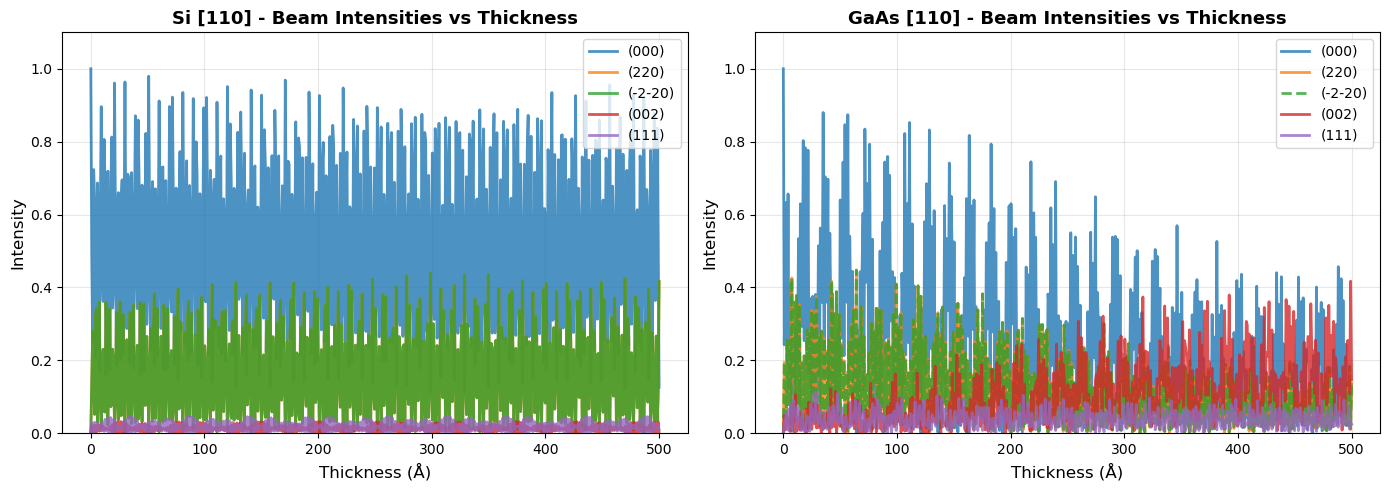


Note the different oscillation patterns for (220) and (-2-20) in GaAs!


In [11]:
# Find indices of key reflections
key_reflections = {
    '(000)': [0, 0, 0],
    '(220)': [2, -2, 0],
    '(-2-20)': [-2, 2, 0],
    '(002)': [0, 0, 2],
    '(111)': [1, -1, 1],
}

indices_Si = {}
indices_GaAs = {}

for name, hkl in key_reflections.items():
    idx = np.where((reflections_110 == hkl).all(axis=1))[0]
    if len(idx) > 0:
        indices_Si[name] = idx[0]
        indices_GaAs[name] = idx[0]

# Plot Si intensities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, idx in indices_Si.items():
    if np.max(I_Si[idx, :]) > 0.01:  # Only plot if significant intensity
        ax1.plot(thickness_range, I_Si[idx, :], label=name, linewidth=2, alpha=0.8)

ax1.set_xlabel('Thickness (Å)', fontsize=12)
ax1.set_ylabel('Intensity', fontsize=12)
ax1.set_title('Si [110] - Beam Intensities vs Thickness', fontsize=13, weight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.1])

# Plot GaAs intensities
for name, idx in indices_GaAs.items():
    if np.max(I_GaAs[idx, :]) > 0.01:  # Only plot if significant intensity
        linestyle = '--' if name == '(-2-20)' else '-'
        ax2.plot(thickness_range, I_GaAs[idx, :], label=name, linewidth=2, alpha=0.8, linestyle=linestyle)

ax2.set_xlabel('Thickness (Å)', fontsize=12)
ax2.set_ylabel('Intensity', fontsize=12)
ax2.set_title('GaAs [110] - Beam Intensities vs Thickness', fontsize=13, weight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

print("\nNote the different oscillation patterns for (220) and (-2-20) in GaAs!")

## Visualization: Direct Comparison of Friedel Pair Asymmetry

Focus on the (220) vs ($\bar{2}\bar{2}$0) reflections to clearly demonstrate the breakdown of Friedel's law in GaAs.

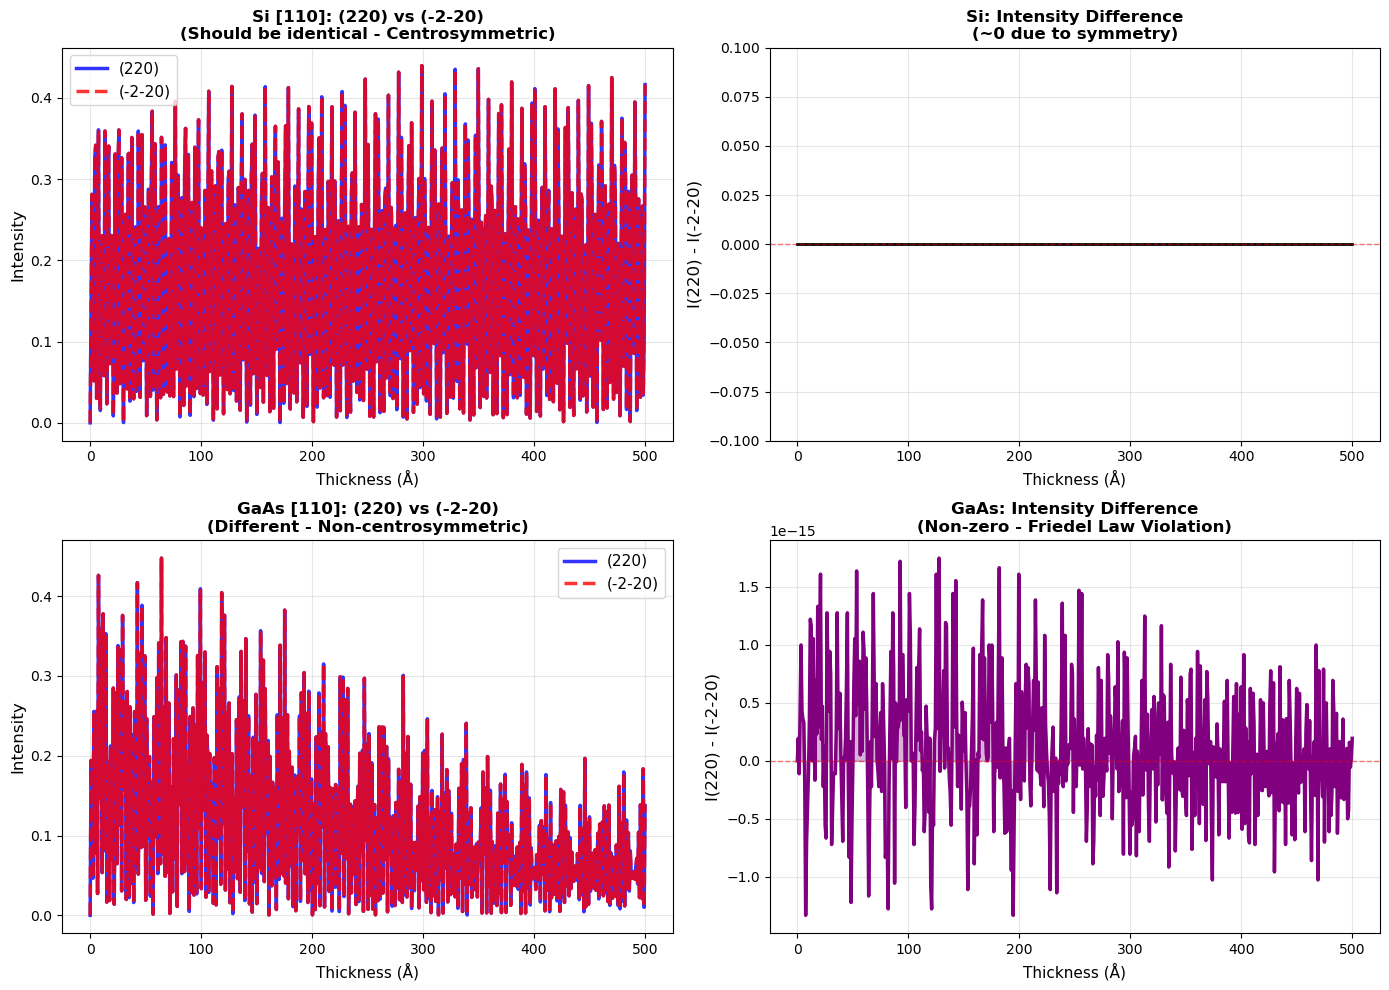


Friedel's Law Violation Statistics (GaAs):
Maximum intensity difference: 0.0000
RMS intensity difference: 0.0000

This asymmetry is a signature of non-centrosymmetric crystals!


In [12]:
# Compare (220) and (-2-20) directly
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Si: (220) vs (-2-20) - should be identical
if '(220)' in indices_Si and '(-2-20)' in indices_Si:
    idx_220_Si = indices_Si['(220)']
    idx_m220_Si = indices_Si['(-2-20)']
    
    ax = axes[0, 0]
    ax.plot(thickness_range, I_Si[idx_220_Si, :], 'b-', linewidth=2.5, label='(220)', alpha=0.8)
    ax.plot(thickness_range, I_Si[idx_m220_Si, :], 'r--', linewidth=2.5, label='(-2-20)', alpha=0.8)
    ax.set_xlabel('Thickness (Å)', fontsize=11)
    ax.set_ylabel('Intensity', fontsize=12)
    ax.set_title('Si [110]: (220) vs (-2-20)\n(Should be identical - Centrosymmetric)', fontsize=12, weight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    
    # Difference plot
    ax = axes[0, 1]
    difference_Si = I_Si[idx_220_Si, :] - I_Si[idx_m220_Si, :]
    ax.plot(thickness_range, difference_Si, 'k-', linewidth=2)
    ax.axhline(0, color='r', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xlabel('Thickness (Å)', fontsize=11)
    ax.set_ylabel('I(220) - I(-2-20)', fontsize=12)
    ax.set_title('Si: Intensity Difference\n(~0 due to symmetry)', fontsize=12, weight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim([-0.1, 0.1])

# GaAs: (220) vs (-2-20) - should be different
if '(220)' in indices_GaAs and '(-2-20)' in indices_GaAs:
    idx_220_GaAs = indices_GaAs['(220)']
    idx_m220_GaAs = indices_GaAs['(-2-20)']
    
    ax = axes[1, 0]
    ax.plot(thickness_range, I_GaAs[idx_220_GaAs, :], 'b-', linewidth=2.5, label='(220)', alpha=0.8)
    ax.plot(thickness_range, I_GaAs[idx_m220_GaAs, :], 'r--', linewidth=2.5, label='(-2-20)', alpha=0.8)
    ax.set_xlabel('Thickness (Å)', fontsize=11)
    ax.set_ylabel('Intensity', fontsize=12)
    ax.set_title('GaAs [110]: (220) vs (-2-20)\n(Different - Non-centrosymmetric)', fontsize=12, weight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    
    # Difference plot
    ax = axes[1, 1]
    difference_GaAs = I_GaAs[idx_220_GaAs, :] - I_GaAs[idx_m220_GaAs, :]
    ax.plot(thickness_range, difference_GaAs, 'purple', linewidth=2.5)
    ax.axhline(0, color='r', linewidth=1, linestyle='--', alpha=0.5)
    ax.fill_between(thickness_range, 0, difference_GaAs, alpha=0.3, color='purple')
    ax.set_xlabel('Thickness (Å)', fontsize=11)
    ax.set_ylabel('I(220) - I(-2-20)', fontsize=12)
    ax.set_title('GaAs: Intensity Difference\n(Non-zero - Friedel Law Violation)', fontsize=12, weight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate statistics
if '(220)' in indices_GaAs and '(-2-20)' in indices_GaAs:
    max_diff_GaAs = np.max(np.abs(difference_GaAs))
    rms_diff_GaAs = np.sqrt(np.mean(difference_GaAs**2))
    
    print(f"\nFriedel's Law Violation Statistics (GaAs):")
    print(f"Maximum intensity difference: {max_diff_GaAs:.4f}")
    print(f"RMS intensity difference: {rms_diff_GaAs:.4f}")
    print(f"\nThis asymmetry is a signature of non-centrosymmetric crystals!")

## Summary

We successfully applied the Bloch-wave method to real crystal structures and demonstrated key differences between centrosymmetric and non-centrosymmetric materials:


**1. Structure Factors:**
- Si (centrosymmetric): $F_{\mathbf{g}} = F_{-\mathbf{g}}$ (Friedel's law holds)
- GaAs (non-centrosymmetric): $F_{\mathbf{g}} \neq F_{-\mathbf{g}}$ (Friedel's law violated)

**2. Bloch-Wave Solutions:**
- Both Si and GaAs have complex eigenvalue spectra
- Multiple Bloch waves excited by the incident beam
- Eigenvalues determine propagation characteristics

**3. Intensity Oscillations:**
- Si: Symmetric intensity evolution for Friedel pairs like (220) and ($\bar{2}\bar{2}$0)
- GaAs: **Asymmetric** intensity evolution - clear signature of non-centrosymmetry
- Thickness-dependent intensity modulation (pendellösung)

**4. Practical Implications:**
- CBED patterns from non-centrosymmetric crystals show asymmetry
- Critical for determining crystal polarity and handedness
- Important for materials like GaAs, GaN, ZnO (polar semiconductors)

### Physical Insight:
The **breakdown of Friedel's law** in non-centrosymmetric crystals is a powerful tool for:
- Crystal structure determination
- Polarity identification in polar materials
- Phase identification in complex materials

### Next Steps:
- Compare with experimental CBED patterns
- Extend to other zone axes ([100], [111])
- Include absorption (imaginary potential)
- Systematic row analysis